# Jobsheet 3 - Operasi Dasar Pengolahan Citra

Nama: Wahyu Fairuz Daniswara  
NIM: 244107020225  
Kelas: TI-2I

Mata Kuliah: Pengolahan Citra dan Visi Komputer

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os

image_folder = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images'

print("Isi folder Images:")
print(os.listdir(image_folder))

Isi folder Images:
['noises', 'Object Detection', 'male.tiff', 'Leaf Images', 'female.tiff', 'couple.tiff', 'facedet', 'balloon.jpg', 'corak.bmp', 'contoh hasil.png', '2D Geometry Images', 'galaxy.jpg', 'gradient.jpg', 'haarcascades', 'Rice Leaf Disease', 'j.png', 'fingerprint.png', 'peppers.jpg', 'lena_lc.jpg', 'sailboat.tiff', 'mandrill.tiff', 'teeth.jpg', 'lena.jpg', 'tobacco.jpg', 'Underexposed_photo.JPG', 'leaves.jpg', 'ktp1.jpg', 'morphology.png', 'kitten01.jpg', 'KTM Lama.jpg', 'jungle.png', 'sudoku-original.jpg', 'lily.jpg', 'sunset.jpg', 'djawatan.jpg', 'tank.tiff', 'wiki.jpg', 'crayfish_enhanced.jpg', 'rose_pink.png', 'crossword.jpg', 'testlena2.jpg', 'old_house.jpg', 'noisy2.png', 'mandrill2.tiff', 'crayfish.jpg', 'testlena.jpg', 'peppers.tiff', 'lena_gs_lc2.jpg', 'lena_gs_lc.jpg', 'houses.jpg', 'KTM Baru.jpg']


In [7]:
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

print("File exists:", os.path.exists(image_path))

File exists: True


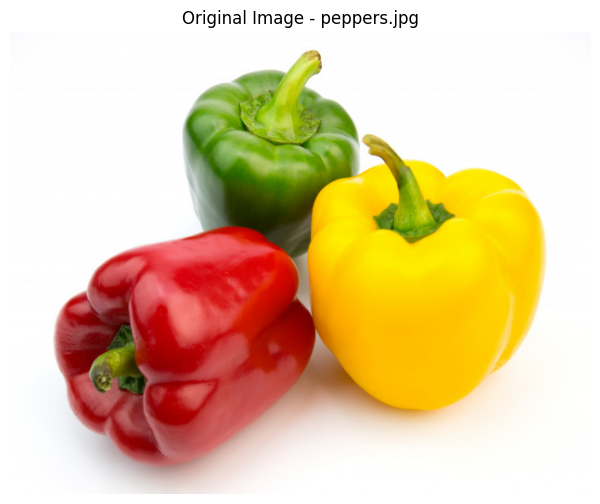

In [8]:
original = cv.imread(image_path)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(original_rgb)
plt.title('Original Image - peppers.jpg')
plt.axis('off')
plt.show()

# Tugas 1 - Inverse Citra

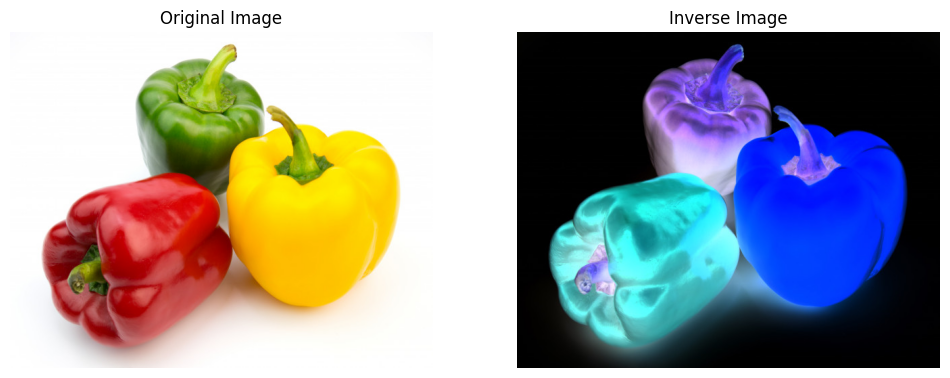

In [9]:
inverse_image = 255 - original

inverse_rgb = cv.cvtColor(inverse_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inverse_rgb)
plt.title('Inverse Image')
plt.axis('off')

plt.show()

# Tugas 2 - Transformasi Contrast

Transformasi Contrast pada Citra
--------------------------------
Masukkan nilai contrast (-255 sampai 255): 50


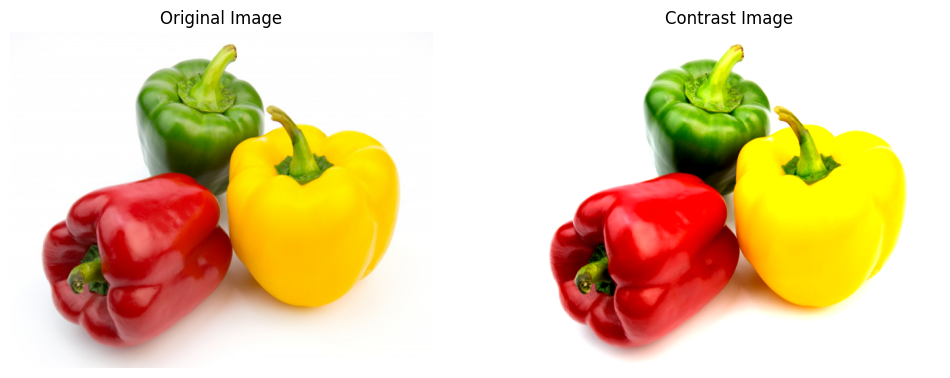

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Fungsi truncate
def truncate(value):
    if value < 0:
        return 0
    elif value > 255:
        return 255
    else:
        return value

# Membaca gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

original = cv.imread(image_path)

# Cek apakah gambar berhasil dibaca
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # Konversi BGR ke RGB
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Input nilai contrast
    print('Transformasi Contrast pada Citra')
    print('--------------------------------')

    contrast = int(input('Masukkan nilai contrast (-255 sampai 255): '))

    # Menghitung Contrast Correction Factor
    factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

    # Membuat salinan gambar
    contrast_image = original.copy()

    # Proses setiap pixel
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                new_value = factor * (int(original[y, x, c]) - 128) + 128

                contrast_image[y, x, c] = truncate(int(new_value))

    # Konversi hasil dari BGR ke RGB
    contrast_rgb = cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB)

    # Menampilkan gambar
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(contrast_rgb)
    plt.title('Contrast Image')
    plt.axis('off')

    plt.show()

# Tugas 3 - Transformasi Logarithmic Brightness

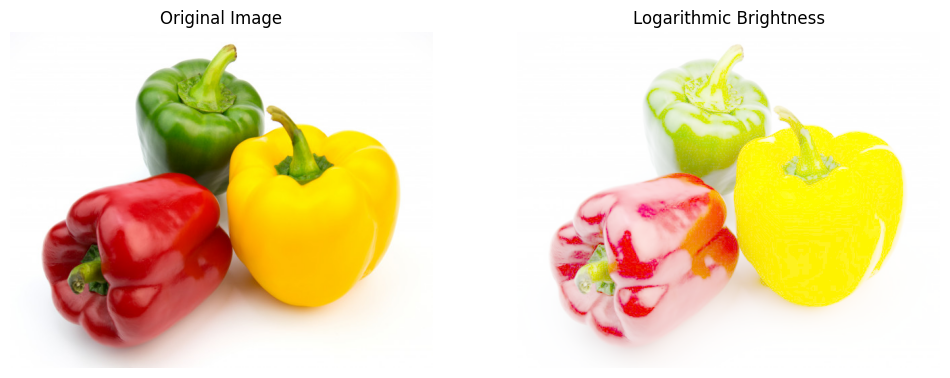

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

original = cv.imread(image_path)

# Cek apakah gambar berhasil dibaca
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # Konversi BGR ke RGB
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Mengubah gambar ke float
    image_float = original.astype(np.float32)

    # Nilai konstanta c
    c = 255 / np.log(1 + np.max(image_float))

    # Transformasi logarithmic
    log_image = c * np.log(1 + image_float)

    # Membatasi nilai pixel 0-255
    log_image = np.clip(log_image, 0, 255)

    # Mengubah kembali ke uint8
    log_image = log_image.astype(np.uint8)

    # Konversi BGR ke RGB
    log_rgb = cv.cvtColor(log_image, cv.COLOR_BGR2RGB)

    # Menampilkan hasil
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(log_rgb)
    plt.title('Logarithmic Brightness')
    plt.axis('off')

    plt.show()

# Tugas 4 - Grayscale
# Averaging, Lightness, dan Luminance


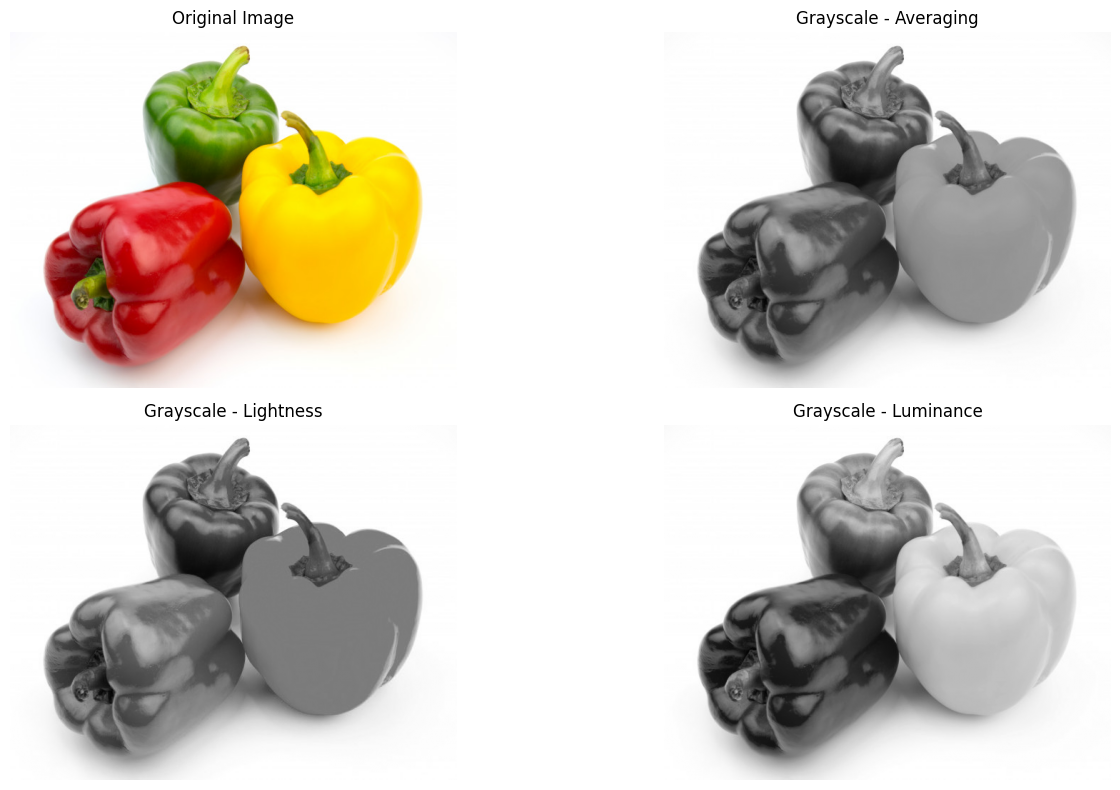

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

# Membaca gambar
original = cv.imread(image_path)

# Cek gambar
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # OpenCV membaca gambar dalam format BGR
    # Kita ubah ke RGB agar sesuai dengan rumus pada modul
    image_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Pisahkan channel RGB
    R = image_rgb[:, :, 0].astype(np.float32)
    G = image_rgb[:, :, 1].astype(np.float32)
    B = image_rgb[:, :, 2].astype(np.float32)

    # ==========================================
    # 1. AVERAGING
    # Rumus: (R + G + B) / 3
    # ==========================================
    averaging = (R + G + B) / 3
    averaging = np.clip(averaging, 0, 255).astype(np.uint8)

    # ==========================================
    # 2. LIGHTNESS
    # Rumus: (max(R,G,B) + min(R,G,B)) / 2
    # ==========================================
    maximum = np.maximum(np.maximum(R, G), B)
    minimum = np.minimum(np.minimum(R, G), B)

    lightness = (maximum + minimum) / 2
    lightness = np.clip(lightness, 0, 255).astype(np.uint8)

    # ==========================================
    # 3. LUMINANCE
    # Rumus: 0.21R + 0.72G + 0.07B
    # ==========================================
    luminance = (0.21 * R) + (0.72 * G) + (0.07 * B)
    luminance = np.clip(luminance, 0, 255).astype(np.uint8)

    # ==========================================
    # MENAMPILKAN HASIL
    # ==========================================
    plt.figure(figsize=(15, 8))

    # Original
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # Averaging
    plt.subplot(2, 2, 2)
    plt.imshow(averaging, cmap='gray')
    plt.title('Grayscale - Averaging')
    plt.axis('off')

    # Lightness
    plt.subplot(2, 2, 3)
    plt.imshow(lightness, cmap='gray')
    plt.title('Grayscale - Lightness')
    plt.axis('off')

    # Luminance
    plt.subplot(2, 2, 4)
    plt.imshow(luminance, cmap='gray')
    plt.title('Grayscale - Luminance')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tugas 5 - Red Channel dan Grayscale Channel Lain


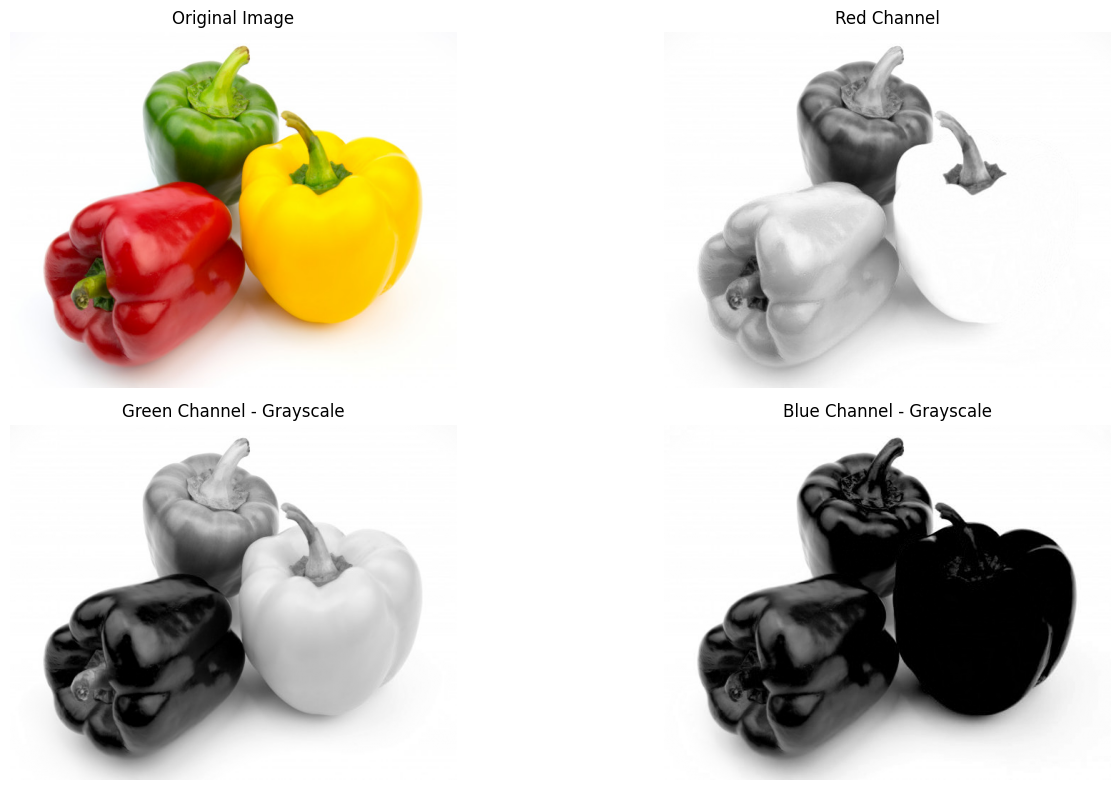

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

# Membaca gambar
original = cv.imread(image_path)

# Cek gambar
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # OpenCV membaca dalam format BGR
    image_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Memisahkan channel RGB
    R = image_rgb[:, :, 0]
    G = image_rgb[:, :, 1]
    B = image_rgb[:, :, 2]

    # ==========================================
    # RED CHANNEL
    # ==========================================
    red_channel = R

    # ==========================================
    # GRAYSCALE DARI GREEN CHANNEL
    # ==========================================
    green_gray = G

    # ==========================================
    # GRAYSCALE DARI BLUE CHANNEL
    # ==========================================
    blue_gray = B

    # ==========================================
    # MENAMPILKAN HASIL
    # ==========================================
    plt.figure(figsize=(15, 8))

    # Original
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # Red Channel
    plt.subplot(2, 2, 2)
    plt.imshow(red_channel, cmap='gray')
    plt.title('Red Channel')
    plt.axis('off')

    # Green Channel
    plt.subplot(2, 2, 3)
    plt.imshow(green_gray, cmap='gray')
    plt.title('Green Channel - Grayscale')
    plt.axis('off')

    # Blue Channel
    plt.subplot(2, 2, 4)
    plt.imshow(blue_gray, cmap='gray')
    plt.title('Blue Channel - Grayscale')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tugas 6 - Gamma Correction


Gamma Correction
-----------------
Masukkan nilai gamma: 2


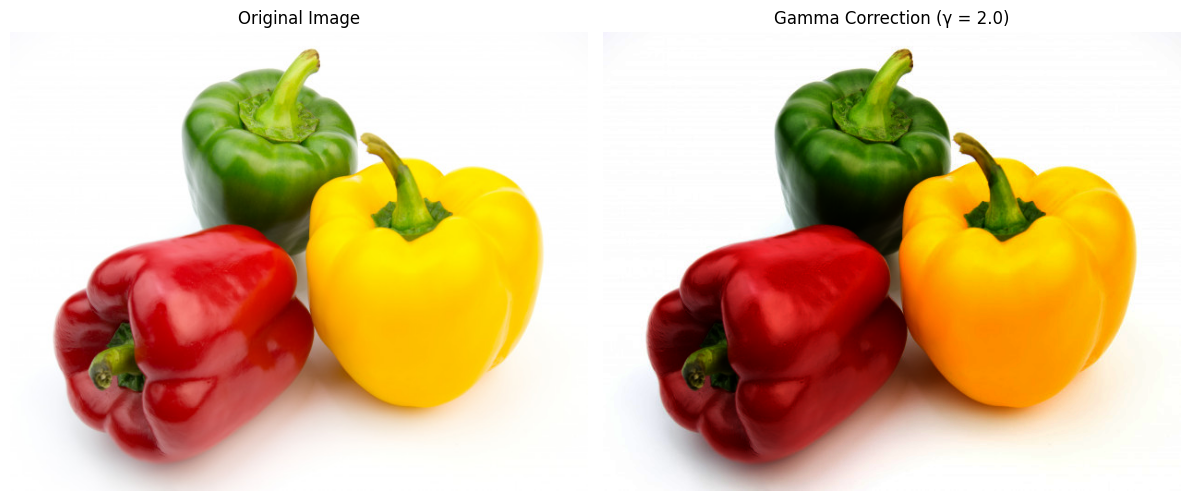

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

# Membaca gambar
original = cv.imread(image_path)

# Cek gambar
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # Konversi BGR ke RGB
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Input nilai gamma
    print("Gamma Correction")
    print("-----------------")
    gamma = float(input("Masukkan nilai gamma: "))

    # Mengecek nilai gamma
    if gamma <= 0:
        print("Nilai gamma harus lebih besar dari 0.")
    else:
        # Konversi gambar ke float
        image_float = original_rgb.astype(np.float32)

        # Gamma correction
        gamma_image = 255 * ((image_float / 255) ** gamma)

        # Membatasi nilai pixel 0-255
        gamma_image = np.clip(gamma_image, 0, 255)

        # Mengubah ke uint8
        gamma_image = gamma_image.astype(np.uint8)

        # Menampilkan hasil
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_rgb)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(gamma_image)
        plt.title(f'Gamma Correction (γ = {gamma})')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Tugas 7 - Image Depth / Bit Depth

Image Depth Simulation
----------------------
Masukkan bit depth (1-7): 7


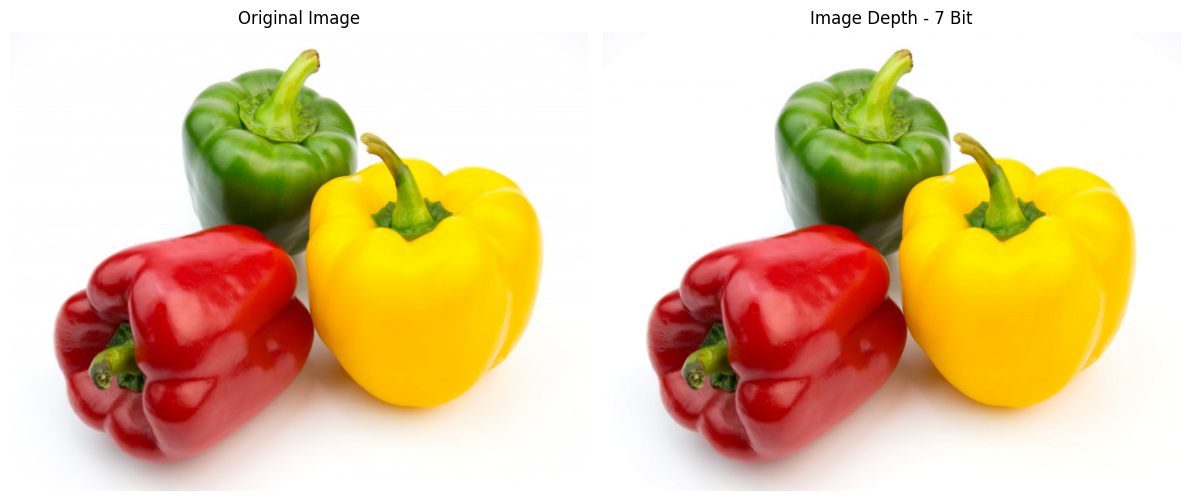

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

# Membaca gambar
original = cv.imread(image_path)

# Cek gambar
if original is None:
    print("Gambar tidak ditemukan!")
else:
    # Konversi BGR ke RGB
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Input bit depth
    print("Image Depth Simulation")
    print("----------------------")
    bit_depth = int(input("Masukkan bit depth (1-7): "))

    if bit_depth < 1 or bit_depth > 7:
        print("Bit depth harus antara 1 sampai 7.")
    else:
        # Menghitung level berdasarkan bit depth
        level = 255 / (2 ** bit_depth - 1)

        # Simulasi image depth
        depth_image = np.round(
            original_rgb / level
        ) * level

        # Membatasi nilai pixel
        depth_image = np.clip(depth_image, 0, 255)

        # Mengubah tipe data
        depth_image = depth_image.astype(np.uint8)

        # Menampilkan hasil
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_rgb)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(depth_image)
        plt.title(f'Image Depth - {bit_depth} Bit')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Tugas 8 - Average Denoising dan PSNR

Gambar berhasil dibaca.
Ukuran gambar: (498, 626, 3)
100 noisy images berhasil dibuat.
10 images -> PSNR: 28.13 dB
20 images -> PSNR: 28.97 dB
40 images -> PSNR: 29.46 dB
80 images -> PSNR: 29.72 dB
100 images -> PSNR: 29.78 dB


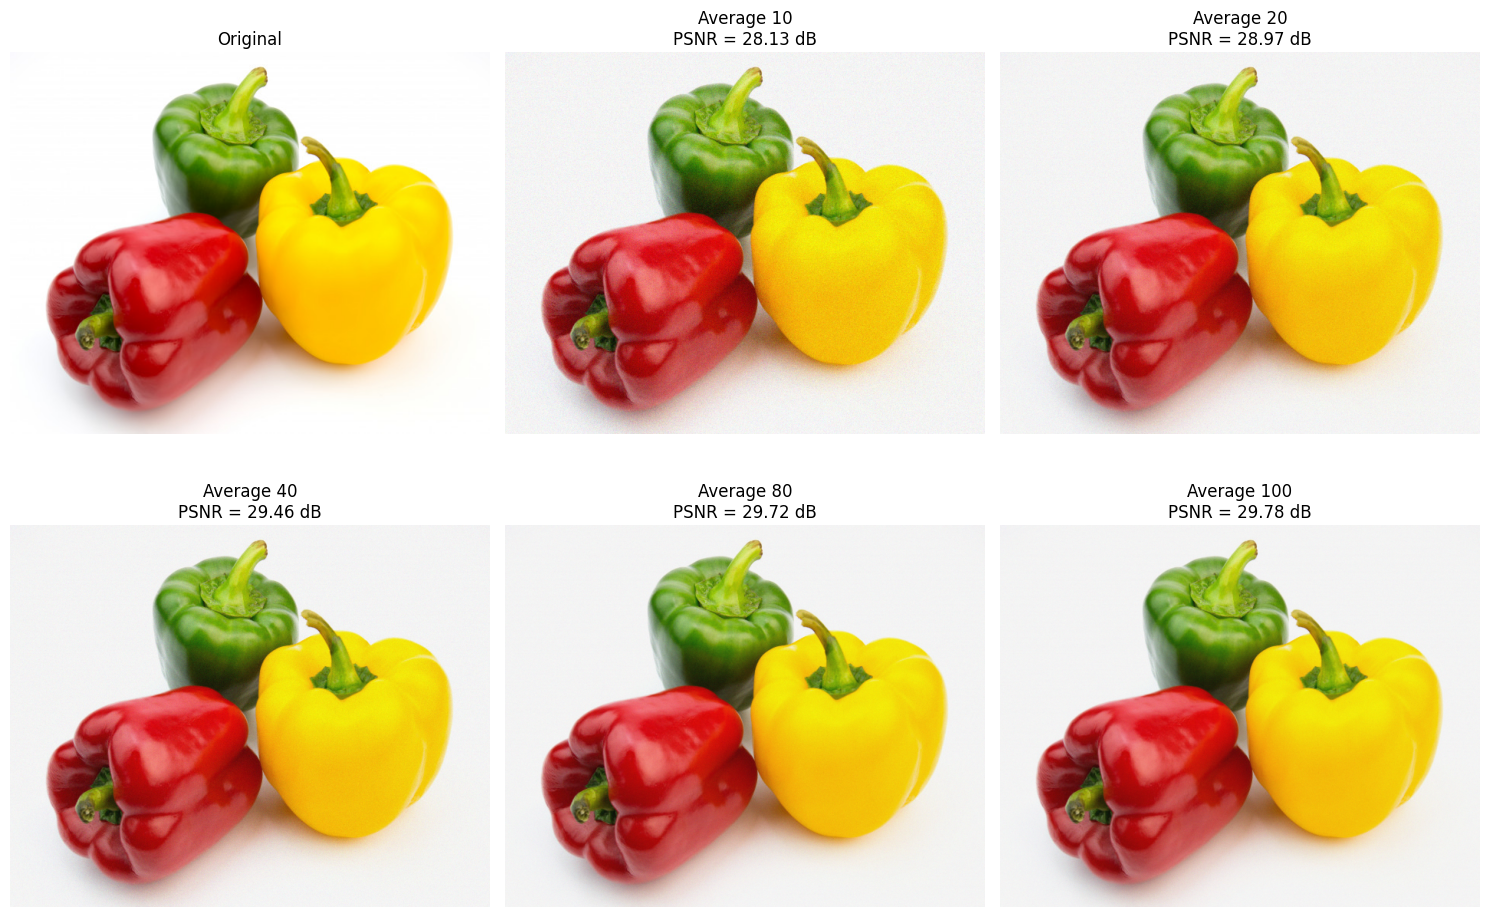

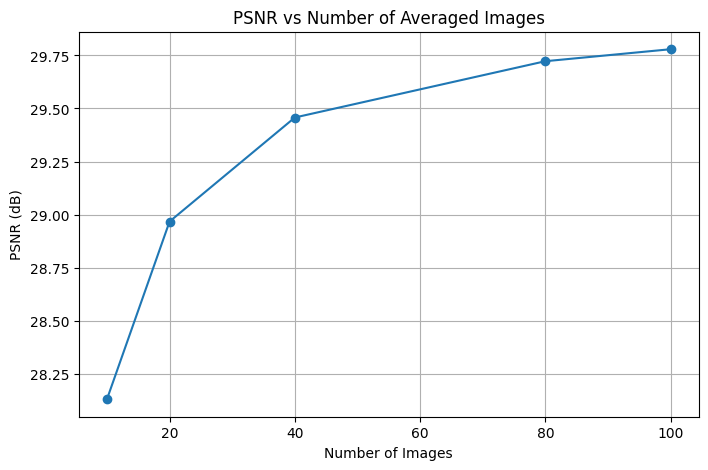

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# ==========================================
# 1. PATH DAN MEMBACA GAMBAR
# ==========================================

image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

original = cv.imread(image_path)

if original is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca.")
    print("Ukuran gambar:", original.shape)

    # ==========================================
    # 2. FUNGSI PSNR
    # ==========================================

    def PSNR(img1, img2):
        mse = np.mean((img1.astype(np.float32) -
                       img2.astype(np.float32)) ** 2)

        if mse == 0:
            return float('inf')

        max_pixel = 255.0
        psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

        return psnr

    # ==========================================
    # 3. MEMBUAT CITRA NOISY
    # ==========================================

    noisy_images = []

    np.random.seed(42)

    for i in range(100):
        # Membuat Gaussian noise
        noise = np.random.normal(
            0,
            25,
            original.shape
        )

        # Menambahkan noise
        noisy = original.astype(np.float32) + noise

        # Membatasi nilai pixel 0-255
        noisy = np.clip(noisy, 0, 255)

        # Mengubah menjadi uint8
        noisy = noisy.astype(np.uint8)

        noisy_images.append(noisy)

    print("100 noisy images berhasil dibuat.")

    # ==========================================
    # 4. AVERAGING
    # ==========================================

    jumlah_images = [10, 20, 40, 80, 100]

    hasil_average = []
    hasil_psnr = []

    for jumlah in jumlah_images:

        # Mengambil sejumlah noisy images
        selected_images = noisy_images[:jumlah]

        # Menjumlahkan semua gambar
        sum_images = np.zeros_like(
            original,
            dtype=np.float32
        )

        for img in selected_images:
            sum_images += img.astype(np.float32)

        # Menghitung rata-rata
        average_image = sum_images / jumlah

        # Membatasi nilai pixel
        average_image = np.clip(
            average_image,
            0,
            255
        )

        # Convert ke uint8
        average_image = average_image.astype(np.uint8)

        # Simpan hasil
        hasil_average.append(average_image)

        # Hitung PSNR
        psnr_value = PSNR(
            original,
            average_image
        )

        hasil_psnr.append(psnr_value)

        print(
            f"{jumlah} images -> PSNR: "
            f"{psnr_value:.2f} dB"
        )

    # ==========================================
    # 5. MENAMPILKAN HASIL
    # ==========================================

    original_rgb = cv.cvtColor(
        original,
        cv.COLOR_BGR2RGB
    )

    plt.figure(figsize=(15, 10))

    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    # Average 10
    plt.subplot(2, 3, 2)
    plt.imshow(
        cv.cvtColor(
            hasil_average[0],
            cv.COLOR_BGR2RGB
        )
    )
    plt.title(f"Average 10\nPSNR = {hasil_psnr[0]:.2f} dB")
    plt.axis("off")

    # Average 20
    plt.subplot(2, 3, 3)
    plt.imshow(
        cv.cvtColor(
            hasil_average[1],
            cv.COLOR_BGR2RGB
        )
    )
    plt.title(f"Average 20\nPSNR = {hasil_psnr[1]:.2f} dB")
    plt.axis("off")

    # Average 40
    plt.subplot(2, 3, 4)
    plt.imshow(
        cv.cvtColor(
            hasil_average[2],
            cv.COLOR_BGR2RGB
        )
    )
    plt.title(f"Average 40\nPSNR = {hasil_psnr[2]:.2f} dB")
    plt.axis("off")

    # Average 80
    plt.subplot(2, 3, 5)
    plt.imshow(
        cv.cvtColor(
            hasil_average[3],
            cv.COLOR_BGR2RGB
        )
    )
    plt.title(f"Average 80\nPSNR = {hasil_psnr[3]:.2f} dB")
    plt.axis("off")

    # Average 100
    plt.subplot(2, 3, 6)
    plt.imshow(
        cv.cvtColor(
            hasil_average[4],
            cv.COLOR_BGR2RGB
        )
    )
    plt.title(f"Average 100\nPSNR = {hasil_psnr[4]:.2f} dB")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ==========================================
    # 6. GRAFIK PSNR
    # ==========================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        jumlah_images,
        hasil_psnr,
        marker='o'
    )

    plt.xlabel("Number of Images")
    plt.ylabel("PSNR (dB)")
    plt.title("PSNR vs Number of Averaged Images")

    plt.grid(True)
    plt.show()

Based on the experiment, increasing the number of images used for averaging improves the PSNR value. The PSNR increased from 28.13 dB with 10 images to 29.78 dB with 100 images. This shows that averaging multiple noisy images can reduce noise and improve image quality. However, the improvement becomes smaller as more images are added.

Tugas 9 - Image Masking
NOT, OR, AND, NAND, XOR


Gambar berhasil dibaca.


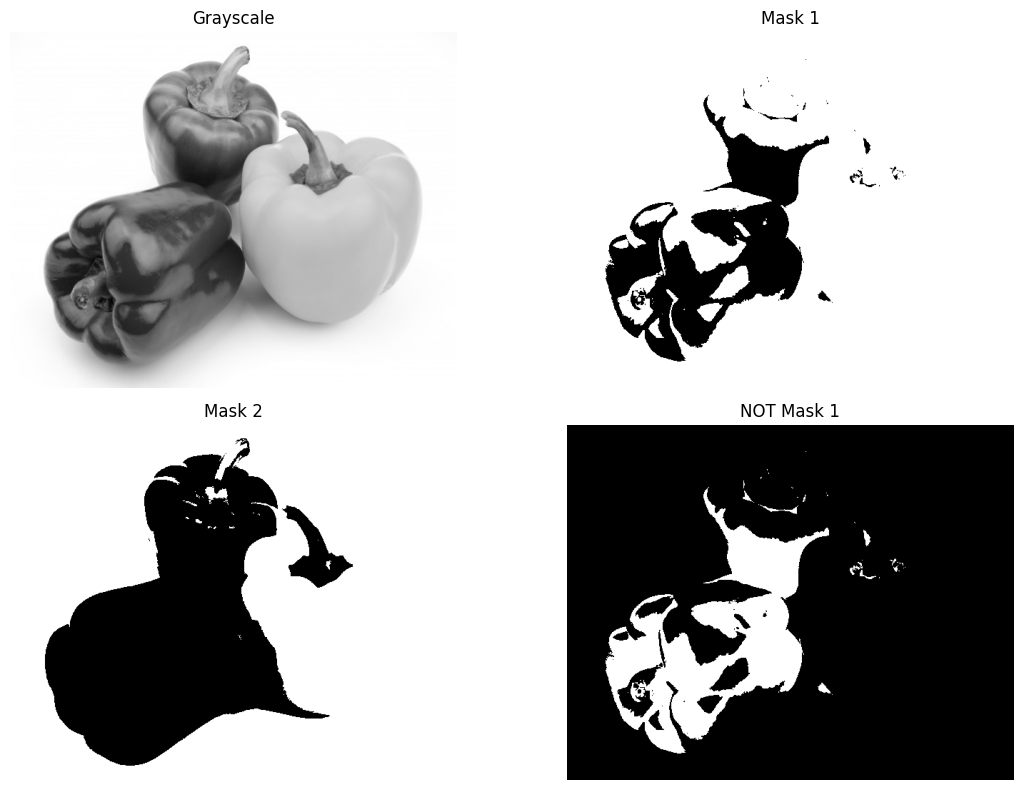

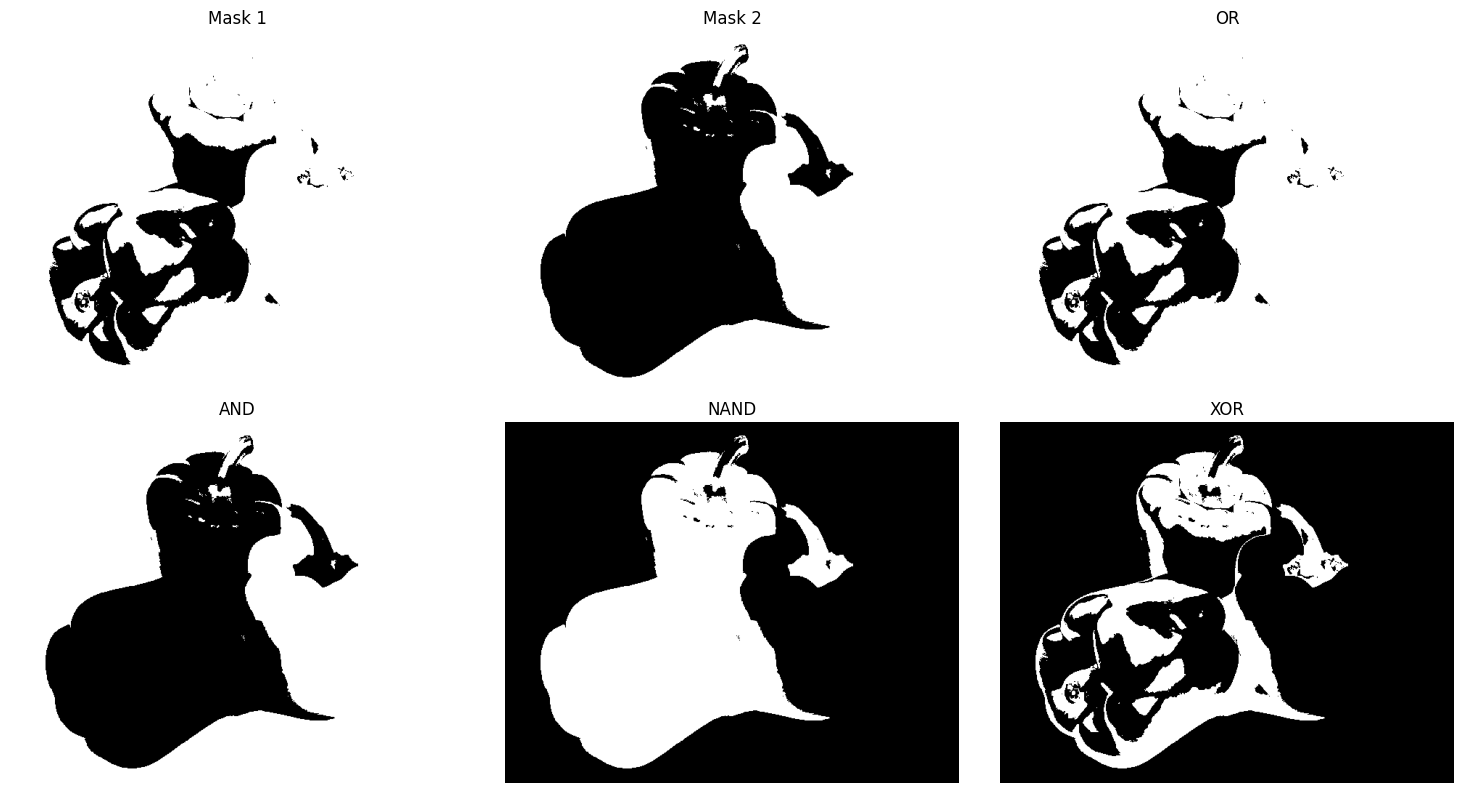

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PATH DAN MEMBACA GAMBAR
# ==========================================

image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/peppers.jpg'

original = cv.imread(image_path)

if original is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca.")

    # ==========================================
    # 2. KONVERSI KE GRAYSCALE
    # ==========================================

    gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

    # ==========================================
    # 3. MEMBUAT MASK
    # ==========================================

    # Threshold pertama
    _, mask1 = cv.threshold(
        gray,
        100,
        255,
        cv.THRESH_BINARY
    )

    # Threshold kedua
    _, mask2 = cv.threshold(
        gray,
        180,
        255,
        cv.THRESH_BINARY
    )

    # ==========================================
    # 4. OPERASI LOGIKA
    # ==========================================

    # NOT
    mask_not = cv.bitwise_not(mask1)

    # OR
    mask_or = cv.bitwise_or(mask1, mask2)

    # AND
    mask_and = cv.bitwise_and(mask1, mask2)

    # NAND
    mask_nand = cv.bitwise_not(mask_and)

    # XOR
    mask_xor = cv.bitwise_xor(mask1, mask2)

    # ==========================================
    # 5. MENAMPILKAN MASK AWAL
    # ==========================================

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(mask1, cmap='gray')
    plt.title('Mask 1')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(mask2, cmap='gray')
    plt.title('Mask 2')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(mask_not, cmap='gray')
    plt.title('NOT Mask 1')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # ==========================================
    # 6. MENAMPILKAN HASIL OPERASI
    # ==========================================

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(mask1, cmap='gray')
    plt.title('Mask 1')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(mask2, cmap='gray')
    plt.title('Mask 2')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(mask_or, cmap='gray')
    plt.title('OR')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(mask_and, cmap='gray')
    plt.title('AND')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(mask_nand, cmap='gray')
    plt.title('NAND')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(mask_xor, cmap='gray')
    plt.title('XOR')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Analysis:
The image masking experiment uses logical operations including NOT, OR, AND, NAND, and XOR. The NOT operation reverses the pixel values of the mask. The OR operation produces a white area when at least one of the two masks contains a white pixel. The AND operation produces a white area only when both masks contain white pixels. NAND is the inverse of the AND operation, while XOR produces a white area when the two masks have different pixel values.

From the experiment, each logical operation produces a different mask pattern depending on the relationship between Mask 1 and Mask 2. These operations can be used to select, combine, or separate specific regions of an image through image masking.

In [21]:
import os
import glob

image_folder = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images'

image_files = []

for extension in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    image_files.extend(
        glob.glob(os.path.join(image_folder, extension))
    )

print("Jumlah gambar:", len(image_files))

for i, file in enumerate(image_files):
    print(i, "->", os.path.basename(file))

Jumlah gambar: 35
0 -> balloon.jpg
1 -> galaxy.jpg
2 -> gradient.jpg
3 -> peppers.jpg
4 -> lena_lc.jpg
5 -> teeth.jpg
6 -> lena.jpg
7 -> tobacco.jpg
8 -> leaves.jpg
9 -> ktp1.jpg
10 -> kitten01.jpg
11 -> KTM Lama.jpg
12 -> sudoku-original.jpg
13 -> lily.jpg
14 -> sunset.jpg
15 -> djawatan.jpg
16 -> wiki.jpg
17 -> crayfish_enhanced.jpg
18 -> crossword.jpg
19 -> testlena2.jpg
20 -> old_house.jpg
21 -> crayfish.jpg
22 -> testlena.jpg
23 -> lena_gs_lc2.jpg
24 -> lena_gs_lc.jpg
25 -> houses.jpg
26 -> KTM Baru.jpg
27 -> contoh hasil.png
28 -> j.png
29 -> fingerprint.png
30 -> morphology.png
31 -> jungle.png
32 -> rose_pink.png
33 -> noisy2.png
34 -> Underexposed_photo.JPG


Tugas 10 - Night Photo Enhancement
Metode: Gamma Correction

Gambar berhasil dibaca.
Ukuran gambar: (820, 960, 3)


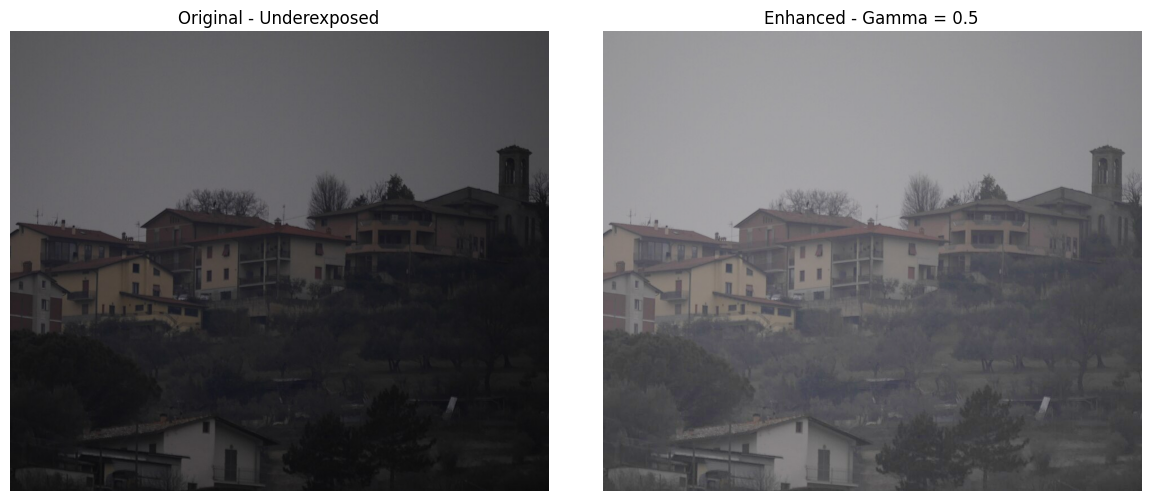

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PATH GAMBAR
# ==========================================

image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/Underexposed_photo.JPG'

# Membaca gambar
original = cv.imread(image_path)

# ==========================================
# 2. CEK GAMBAR
# ==========================================

if original is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca.")
    print("Ukuran gambar:", original.shape)

    # Konversi BGR ke RGB
    original_rgb = cv.cvtColor(
        original,
        cv.COLOR_BGR2RGB
    )

    # ==========================================
    # 3. GAMMA CORRECTION
    # ==========================================

    gamma = 0.5

    # Konversi ke float
    image_float = original_rgb.astype(np.float32)

    # Gamma correction
    enhanced = 255 * (
        (image_float / 255) ** gamma
    )

    # Membatasi nilai pixel
    enhanced = np.clip(
        enhanced,
        0,
        255
    )

    # Konversi ke uint8
    enhanced = enhanced.astype(np.uint8)

    # ==========================================
    # 4. MENAMPILKAN HASIL
    # ==========================================

    plt.figure(figsize=(12, 5))

    # Foto original
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original - Underexposed')
    plt.axis('off')

    # Foto hasil enhancement
    plt.subplot(1, 2, 2)
    plt.imshow(enhanced)
    plt.title(f'Enhanced - Gamma = {gamma}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

The method used for night photo enhancement is Gamma Correction with a gamma value of 0.5. This method was chosen because a gamma value below 1 can increase the brightness of dark areas in an underexposed image. It helps make details in dark regions more visible. However, using a gamma value that is too low can make bright areas overexposed and reduce image contrast.

Tugas 11 - Image Enhancement pada crayfish.jpg

Gambar berhasil dibaca.
Ukuran gambar: (640, 960, 3)


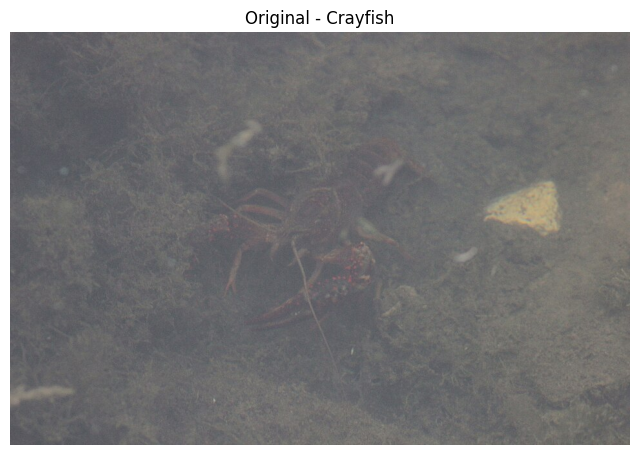

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/Images-20260916T014528Z-1-001/Images/crayfish.jpg'

original = cv.imread(image_path)

if original is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca.")
    print("Ukuran gambar:", original.shape)

    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(original_rgb)
    plt.title('Original - Crayfish')
    plt.axis('off')
    plt.show()

Contrast Enhancement pada crayfish.jpg

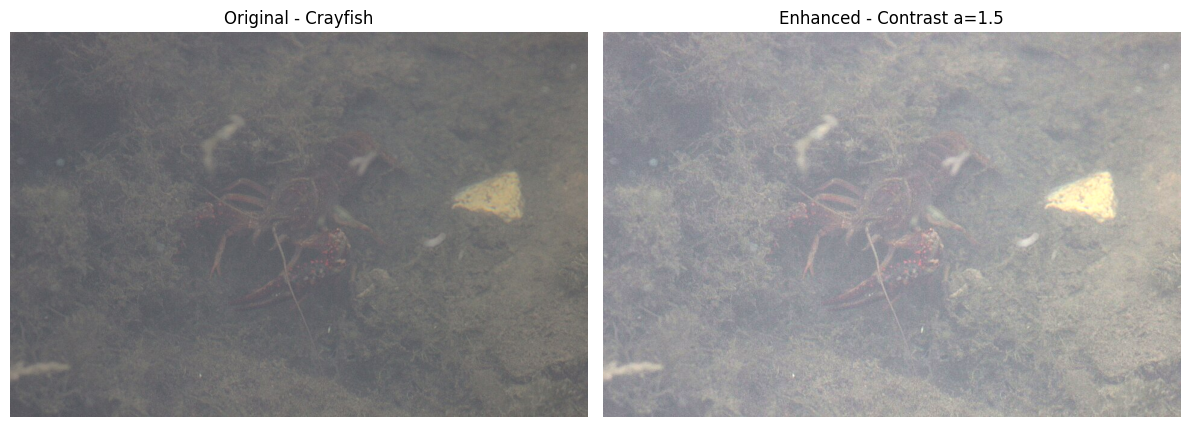

In [24]:
# Parameter contrast
a = 1.5
b = 0

# Konversi ke float agar perhitungan lebih aman
image_float = original_rgb.astype(np.float32)

# Contrast enhancement
enhanced = a * image_float + b

# Batasi nilai pixel agar tetap 0-255
enhanced = np.clip(enhanced, 0, 255)

# Kembalikan ke uint8
enhanced = enhanced.astype(np.uint8)

# Tampilkan perbandingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Original - Crayfish')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title(f'Enhanced - Contrast a={a}')
plt.axis('off')

plt.tight_layout()
plt.show()

The method used to improve the `crayfish.jpg` image is **Contrast Enhancement** using the linear contrast formula `g = a*f + b`.

The parameter used is **a = 1.5** and **b = 0**. The value of `a` greater than 1 increases the contrast between dark and bright pixels, while `b = 0` means that no additional brightness is added.

This method was chosen to make the details and differences between dark and bright areas of the crayfish image more visible. After enhancement, the image has higher contrast compared to the original image.

The result can be seen by comparing the original image with the enhanced image. However, if the contrast factor is set too high, some pixel values may become too bright or too dark. Therefore, the parameter should be adjusted carefully.